In [1]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.chdir("Data Sets")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_athlete_games.csv",low_memory=False)

<class 'matplotlib.figure.Figure'>
<class 'type'>


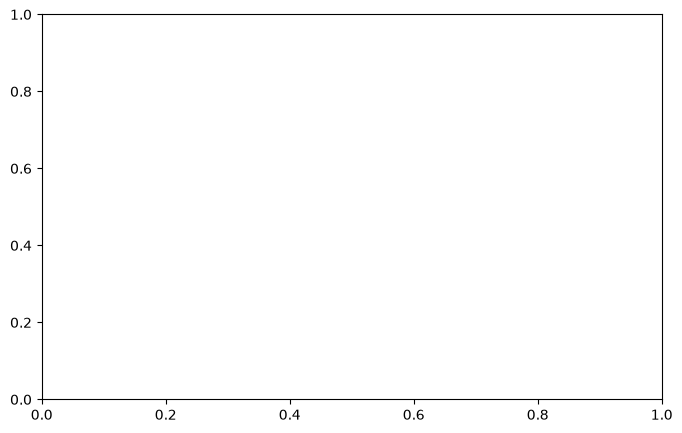

In [4]:
# Matplotlib basics

# syntax - fig, ax=plt.subplots()

# Every matplotlib chart has two parts - the Figure(overall canvas/window can contain multiple charts) and the Axes - (one individual chart/plot area with in that canvas)

# The object oriented API gives you explicit references to both, so you control exactly what you are drawing on.

fig,ax=plt.subplots(figsize=(8,5))
print(type(fig))
print(type)

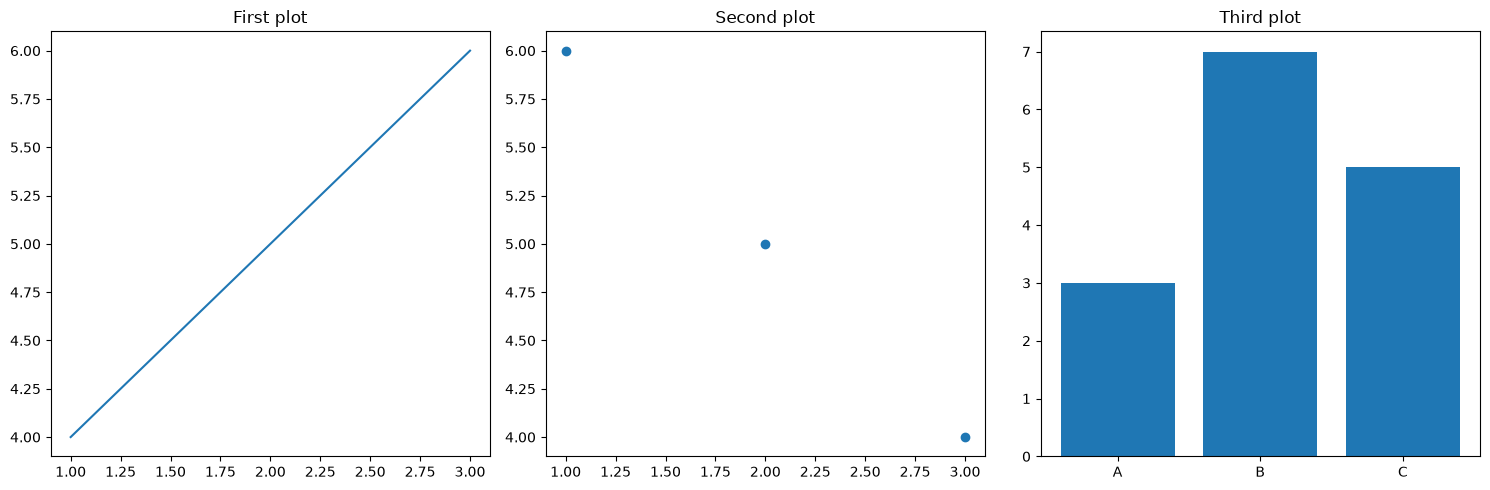

In [5]:
# 1D grid

fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))

# Creates a grid of 1 row and 3 columns

ax1.plot([1,2,3],[4,5,6])
ax1.set_title("First plot")

ax2.scatter([1,2,3],[6,5,4])
ax2.set_title("Second plot")

ax3.bar(["A","B","C"],[3,7,5])
ax3.set_title("Third plot")

plt.tight_layout()
plt.show()

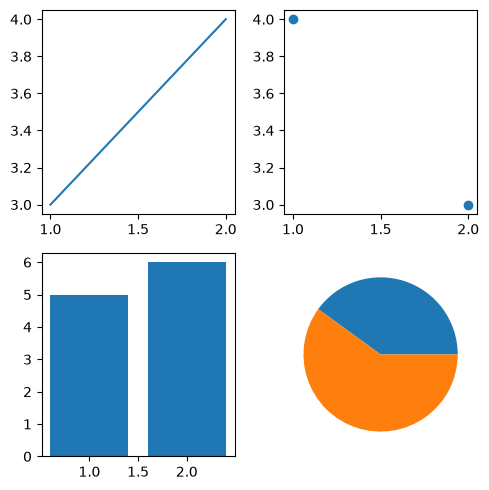

In [6]:
# 2D grid - Rows and columns

fig,ax = plt.subplots(2,2,figsize=(5,5))

# Top left plot(row 0, colum 0)

ax[0,0].plot([1,2],[3,4])

# Top right plot(row 0, colum 1)

ax[0,1].scatter([1,2],[4,3])

# Bottom left plot(row 1, colum 0)

ax[1,0].bar([1,2],[5,6])

# Bottom right plot(row 1, colum 1)

ax[1,1].pie([40,60])

plt.tight_layout()
plt.show()

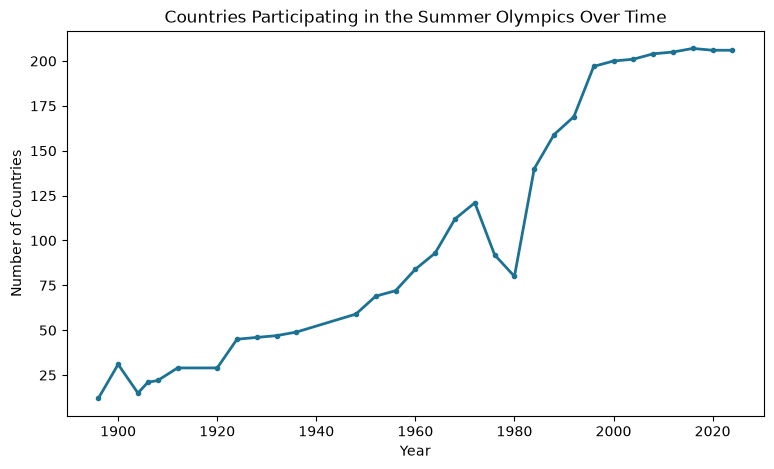

2026
1896


In [22]:
# Plot types - Line, bar, scatter

# syntax - ax.plot(x,y)

summer = df[df["Season"]=="Summer"]
year_nocs = summer.groupby("Year")["NOC"].nunique().reset_index(name="num_countries")

fig,ax = plt.subplots(figsize=(9,5))
ax.plot(year_nocs["Year"],year_nocs["num_countries"],color='#1C7293',linewidth=2,marker='o',markersize=3)
ax.set_title("Countries Participating in the Summer Olympics Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Countries")
plt.show()

# A line chart connects points in order which only makes sense when there is a natural sequence usually time. Hence used for time trend analysis.

# Here we see a steady growth in Olympic history plus dips in 1976 and 1980 (Cold war era boycotts could be the reason).
# A line chart makes a trend like this instantly visible in a way atable of 32 numbers never could.

print(df["Year"].max())
print(df["Year"].min())

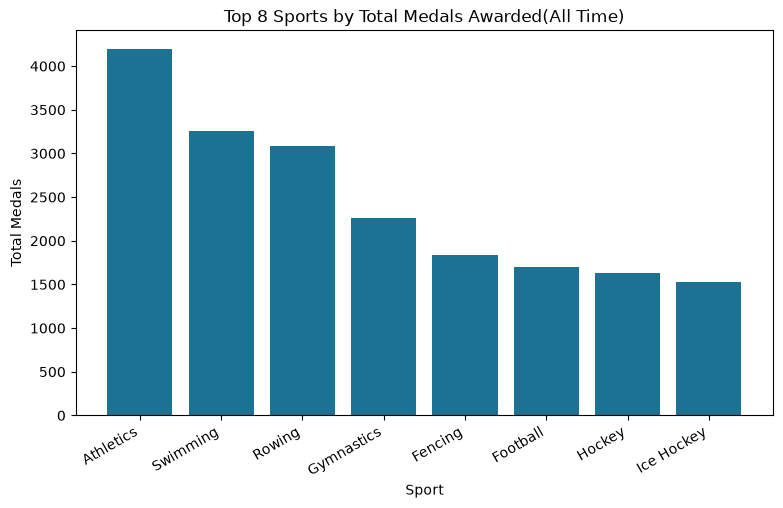

In [9]:
# Bar chart

# Bar is for comparing any categorical data

# syntax = ax.bar(categories,values)

sports_top = df[df["Medal"].notna()].groupby("Sport").size().sort_values(ascending=False).head(8)

fig,ax = plt.subplots(figsize=(9,5))
ax.bar(sports_top.index,sports_top.values,color='#1C7293')
ax.set_title("Top 8 Sports by Total Medals Awarded(All Time)")
ax.set_xlabel('Sport')
ax.set_ylabel('Total Medals')
plt.xticks(rotation=30,ha='right')
plt.show()

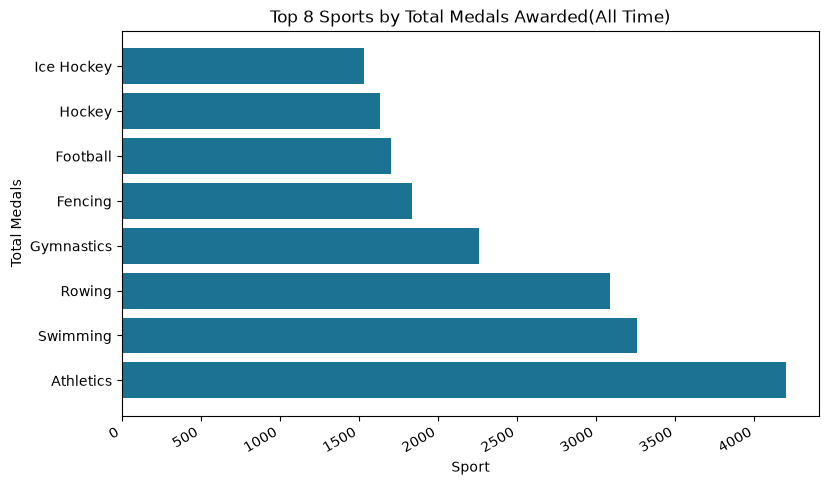

In [10]:
# Bar chart

# Bar is for comparing any categorical data

# syntax = ax.bar(categories,values)

sports_top = df[df["Medal"].notna()].groupby("Sport").size().sort_values(ascending=False).head(8)

fig,ax = plt.subplots(figsize=(9,5))
ax.barh(sports_top.index,sports_top.values,color='#1C7293')
ax.set_title("Top 8 Sports by Total Medals Awarded(All Time)")
ax.set_xlabel('Sport')
ax.set_ylabel('Total Medals')
plt.xticks(rotation=30,ha='right')
plt.show()

| Element      | Method                                | What it controls                                    |
|------------------|----------------------------------------------|--------------------------------------------------------------|
| Title                | ax.set_title("...")                              | The chart's headline                                              |
| Axis labels             | ax.set_xlabel("...") / ax.set_ylabel("...")         | What each axis represents                                            |
| Ticks                     | ax.set_xticks([...]) / ax.set_yticks([...])            | WHICH specific values get marked on each axis                            |
| Legend                      | ax.legend(loc=..., frameon=...)                          | A key identifying multiple lines/series — requires label= on each plot call |
| Annotation                     | ax.annotate("text", xy=, xytext=, arrowprops=)              | Text pointing to a SPECIFIC point on the chart, with an optional arrow    |
| Reference line                    | ax.axhline(value) / ax.axvline(value)                          | A horizontal/vertical guide line at a specific value                        |

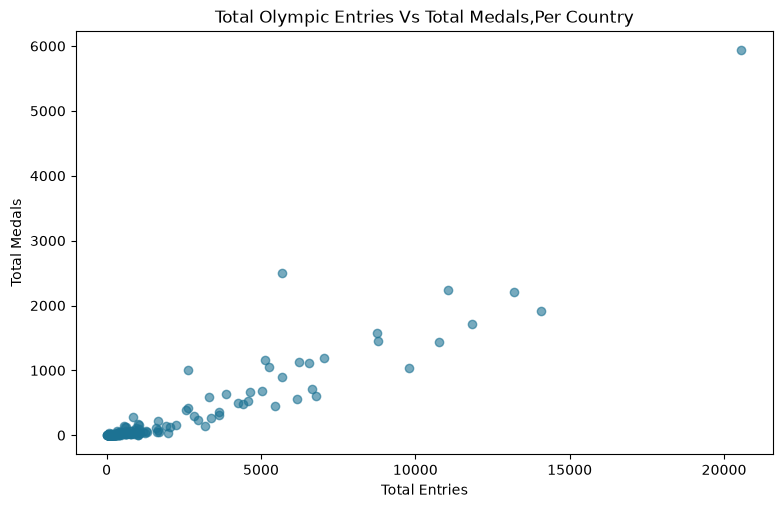

In [20]:
# Scatter plot - for showing relationship between two numeric variables

# syntax - ax.scatter(x,y)

noc_summary = df.groupby("NOC").agg(
    total_entries=("Entry ID","count"),
    total_medals=("Medal", lambda x: x.notna().sum())
).reset_index()
noc_summary = noc_summary[noc_summary["total_entries"]>20]

fig,ax = plt.subplots(figsize=(9,5.5))
ax.scatter(noc_summary["total_entries"],noc_summary["total_medals"],color='#1C7293',alpha=0.6)
ax.set_title("Total Olympic Entries Vs Total Medals,Per Country")
ax.set_xlabel ("Total Entries")
ax.set_ylabel("Total Medals")
plt.show()

# A clear upward sloping cloud of points, with the USA sitting far off by itself in the top-right corner.

# Each dot is one country - its position shows its entry count(x) and medal count(y) at once. this is the visual version of the pearson correlation
# from earlier. you can see a strong relationship and spot USA as an outlier.

| Plot type   | Best for                                        | Matplotlib call         |
|-----------------|--------------------------------------------------------|-------------------------------|
| Line                | Trends over a continuous/ordered variable (usually time)   | ax.plot(x, y)                     |
| Bar                   | Comparing discrete categories                                 | ax.bar(categories, values)            |
| Scatter                  | Relationship between two numeric variables                      | ax.scatter(x, y)                        |

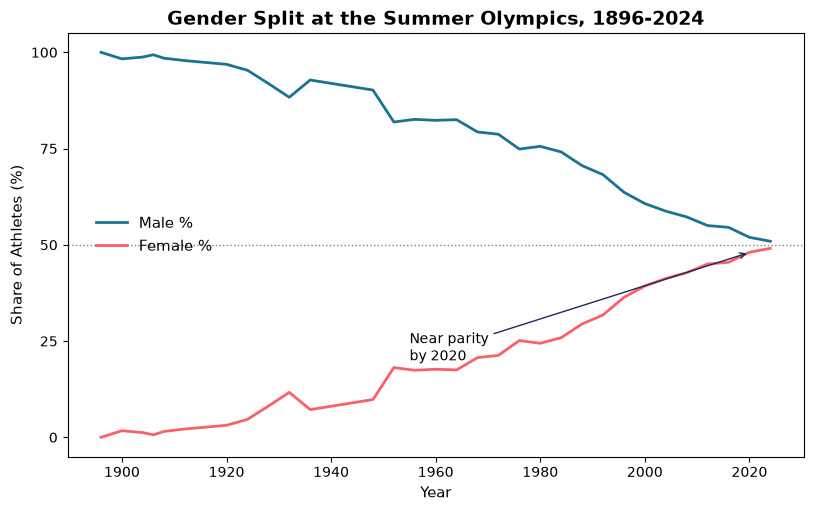

In [23]:
# Customization : Titles, Labels, Ticks, Legends, Annotations

gender_by_year = summer.groupby(["Year","Gender"]).size().unstack(fill_value=0)
gender_pct = gender_by_year.div(gender_by_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(gender_pct.index, gender_pct["Male"], color="#1C7293", linewidth=2, label="Male %")
ax.plot(gender_pct.index, gender_pct["Female"], color="#F96167", linewidth=2, label="Female %")

# TITLE and LABELS
ax.set_title("Gender Split at the Summer Olympics, 1896-2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Share of Athletes (%)", fontsize=11)

# TICKS — controlling exactly which values show on each axis
ax.set_yticks([0,25,50,75,100])
ax.set_xticks(range(1900, 2030, 20))

# LEGEND — identifying which line is which
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.6), frameon=False, fontsize=11)

# A reference line at 50%
ax.axhline(50, color="gray", linestyle=":", linewidth=1)

# ANNOTATION — pointing out a specific insight directly on the chart
ax.annotate("Near parity\nby 2020", xy=(2020, 48), xytext=(1955, 20),
            fontsize=10, arrowprops=dict(arrowstyle="->", color="#21295C"))

plt.show()